<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Opencv_Sensing_Acquisition_Bilinar_Interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Imports (core) ---
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap=None, max_size=900):
    """Display an image (BGR or grayscale) nicely in matplotlib."""
    if img is None:
        raise ValueError("Image is None (check file path).")
    disp = img.copy()
    if disp.ndim == 3 and disp.shape[2] == 3:
        disp = cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)
    h, w = disp.shape[:2]
    scale = min(1.0, max_size / max(h, w))
    if scale < 1.0:
        disp = cv2.resize(disp, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    plt.figure(figsize=(8, 6))
    plt.imshow(disp, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def mse(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return float(np.mean((a - b) ** 2))

def psnr(a, b, max_val=255.0):
    m = mse(a, b)
    if m == 0:
        return float('inf')
    return 10.0 * np.log10((max_val**2) / m)


Loaded: shrek.jpg
Shape (H, W, C): (278, 181, 3) | dtype: uint8


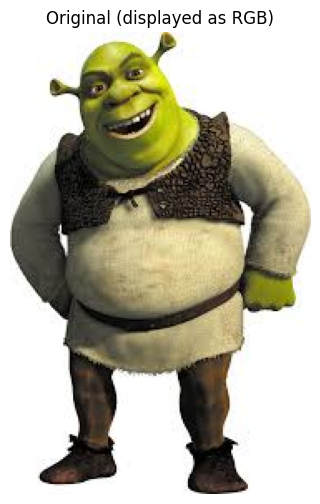

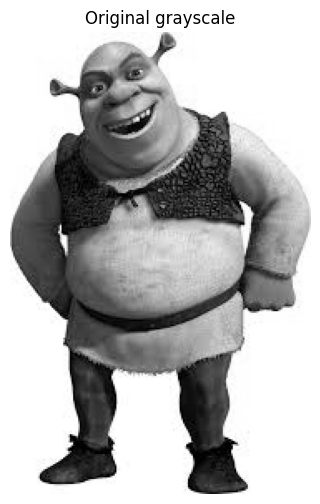

In [ ]:
# --- Set your image path here ---
IMAGE_PATH = "shrek.jpg"  # <- change this

assert IMAGE_PATH != "PUT_YOUR_IMAGE_PATH_HERE.jpg", "Please set IMAGE_PATH to your real image file."
assert os.path.exists(IMAGE_PATH), f"File not found: {IMAGE_PATH}"

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise ValueError("cv2.imread failed. The file may be unreadable or format unsupported.")

print("Loaded:", IMAGE_PATH)
print("Shape (H, W, C):", img_bgr.shape, "| dtype:", img_bgr.dtype)

show(img_bgr, "Original (displayed as RGB)")

# Also display grayscale (luminance-like)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
show(img_gray, "Original grayscale", cmap="gray")


In [ ]:
# Work in float [0,1] for sensing-style operations
img_f = img_bgr.astype(np.float32) / 255.0

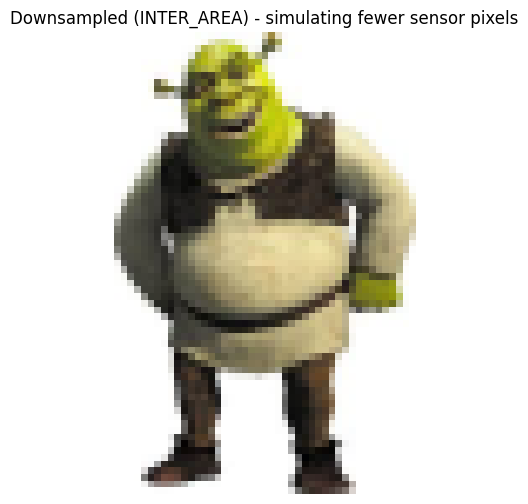

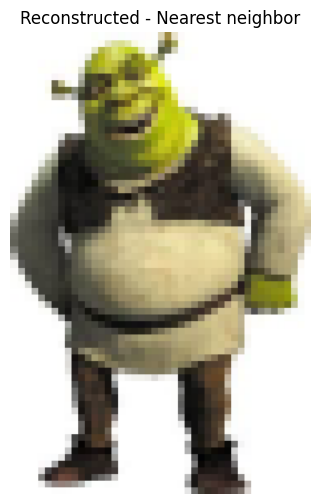

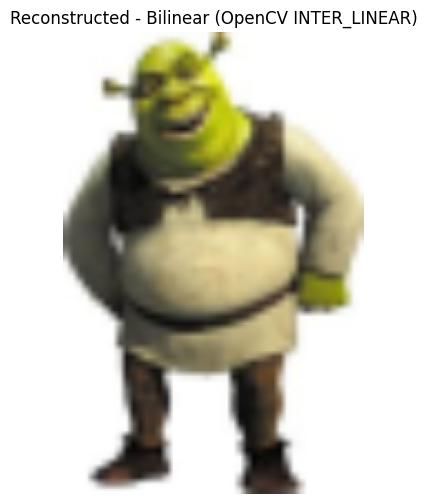

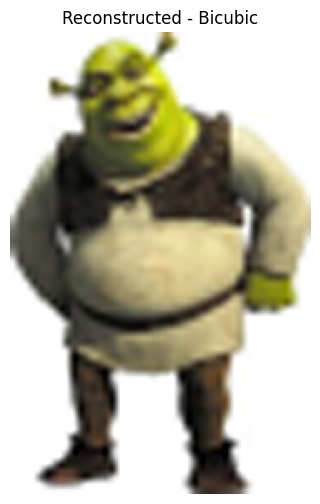

PSNR vs original (higher is better):
Nearest: 19.791334752095306
Linear : 21.252439810534117
Cubic  : 22.085861532281307


In [ ]:
def downsample_and_reconstruct(img_bgr, factor=4):
    h, w = img_bgr.shape[:2]
    small = cv2.resize(img_bgr, (w//factor, h//factor), interpolation=cv2.INTER_AREA)
    nn   = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    lin  = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    cub  = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    return small, nn, lin, cub

small, nn, lin, cub = downsample_and_reconstruct(img_bgr, factor=4)

show(small, "Downsampled (INTER_AREA) - simulating fewer sensor pixels")
show(nn,   "Reconstructed - Nearest neighbor")
show(lin,  "Reconstructed - Bilinear (OpenCV INTER_LINEAR)")
show(cub,  "Reconstructed - Bicubic")

print("PSNR vs original (higher is better):")
print("Nearest:", psnr(img_bgr, nn))
print("Linear :", psnr(img_bgr, lin))
print("Cubic  :", psnr(img_bgr, cub))


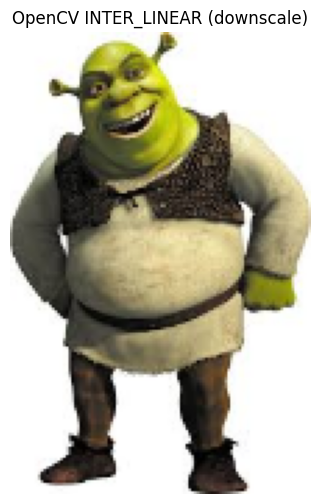

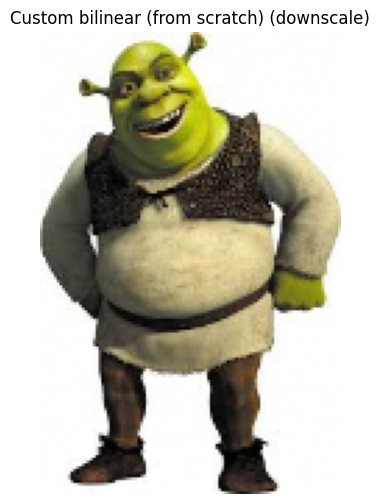

MSE between OpenCV and custom bilinear: 0.290402352809906
PSNR between OpenCV and custom bilinear: 53.50080230216507


In [ ]:
def resize_bilinear_numpy(img, new_w, new_h):
    """Bilinear resize (from scratch) for grayscale or BGR uint8 images.

    - Works on uint8 input.
    - Returns uint8 output.
    - Uses 'align corners' style mapping similar to many libraries:
      src_x = (x + 0.5) * (W / new_w) - 0.5
    """
    if img.ndim == 2:
        img_ = img[..., None]  # HWC with C=1
    else:
        img_ = img

    H, W, C = img_.shape
    out = np.zeros((new_h, new_w, C), dtype=np.float32)

    scale_x = W / new_w
    scale_y = H / new_h

    for y in range(new_h):
        src_y = (y + 0.5) * scale_y - 0.5
        y0 = int(np.floor(src_y))
        y1 = y0 + 1
        dy = src_y - y0

        y0c = np.clip(y0, 0, H-1)
        y1c = np.clip(y1, 0, H-1)

        for x in range(new_w):
            src_x = (x + 0.5) * scale_x - 0.5
            x0 = int(np.floor(src_x))
            x1 = x0 + 1
            dx = src_x - x0

            x0c = np.clip(x0, 0, W-1)
            x1c = np.clip(x1, 0, W-1)

            Ia = img_[y0c, x0c].astype(np.float32)
            Ib = img_[y0c, x1c].astype(np.float32)
            Ic = img_[y1c, x0c].astype(np.float32)
            Id = img_[y1c, x1c].astype(np.float32)

            out[y, x] = (1-dx)*(1-dy)*Ia + dx*(1-dy)*Ib + (1-dx)*dy*Ic + dx*dy*Id

    out = np.clip(out, 0, 255).astype(np.uint8)
    if img.ndim == 2:
        return out[..., 0]
    return out

# Test on a resize task
h, w = img_bgr.shape[:2]
new_w, new_h = int(w*0.6), int(h*0.6)

cv_lin = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
my_lin = resize_bilinear_numpy(img_bgr, new_w, new_h)

show(cv_lin, "OpenCV INTER_LINEAR (downscale)")
show(my_lin, "Custom bilinear (from scratch) (downscale)")

print("MSE between OpenCV and custom bilinear:", mse(cv_lin, my_lin))
print("PSNR between OpenCV and custom bilinear:", psnr(cv_lin, my_lin))


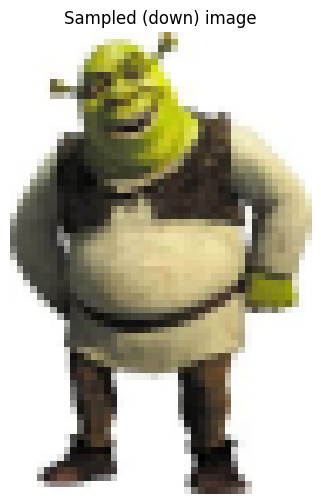

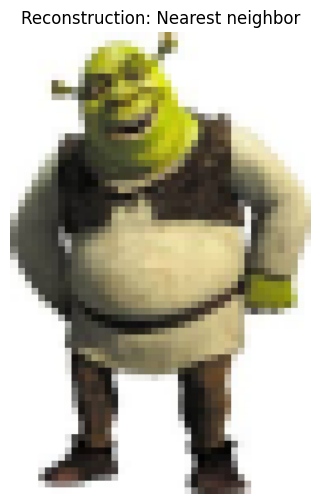

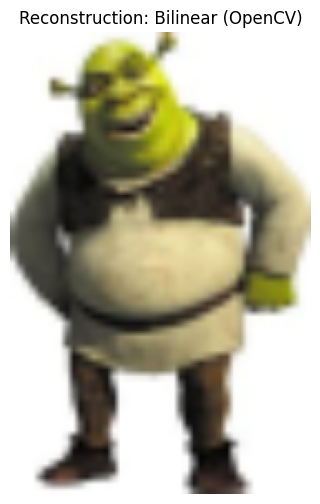

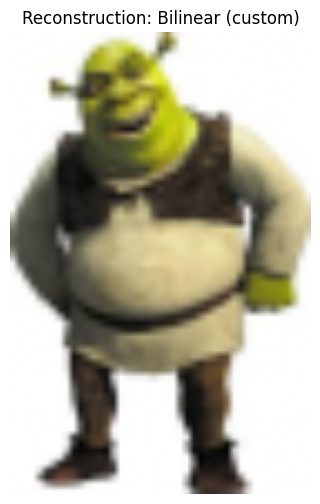

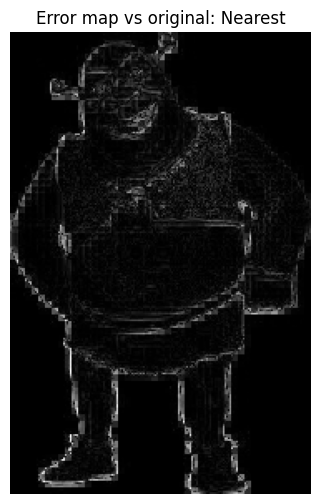

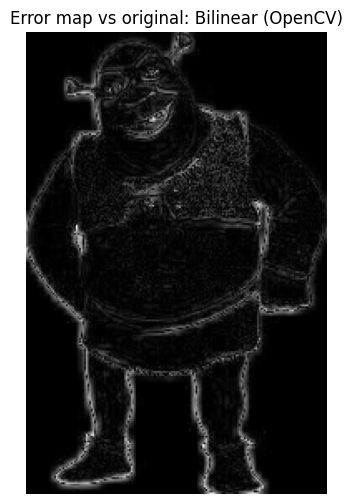

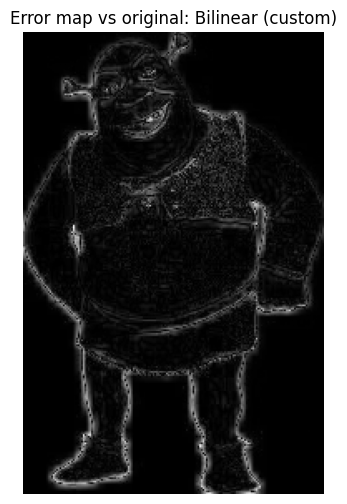

PSNR vs original:
Nearest: 19.791334752095306
Bilinear OpenCV: 21.252439810534117
Bilinear custom: 21.251222435977233


In [ ]:
def error_map(a, b):
    """Compute per-pixel absolute error map (grayscale) from two BGR uint8 images."""
    diff = cv2.absdiff(a, b)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    # Normalize for visualization
    norm = cv2.normalize(diff_gray, None, 0, 255, cv2.NORM_MINMAX)
    return norm

# Sample down, then reconstruct back to original size
factor = 4
h, w = img_bgr.shape[:2]
small = cv2.resize(img_bgr, (w//factor, h//factor), interpolation=cv2.INTER_AREA)

nn   = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
cv_bi= cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
my_bi= resize_bilinear_numpy(small, w, h)  # custom bilinear on the small image

show(small, "Sampled (down) image")
show(nn,    "Reconstruction: Nearest neighbor")
show(cv_bi, "Reconstruction: Bilinear (OpenCV)")
show(my_bi, "Reconstruction: Bilinear (custom)")

err_nn   = error_map(img_bgr, nn)
err_cvbi = error_map(img_bgr, cv_bi)
err_mybi = error_map(img_bgr, my_bi)

show(err_nn,   "Error map vs original: Nearest", cmap="gray")
show(err_cvbi, "Error map vs original: Bilinear (OpenCV)", cmap="gray")
show(err_mybi, "Error map vs original: Bilinear (custom)", cmap="gray")

print("PSNR vs original:")
print("Nearest:", psnr(img_bgr, nn))
print("Bilinear OpenCV:", psnr(img_bgr, cv_bi))
print("Bilinear custom:", psnr(img_bgr, my_bi))


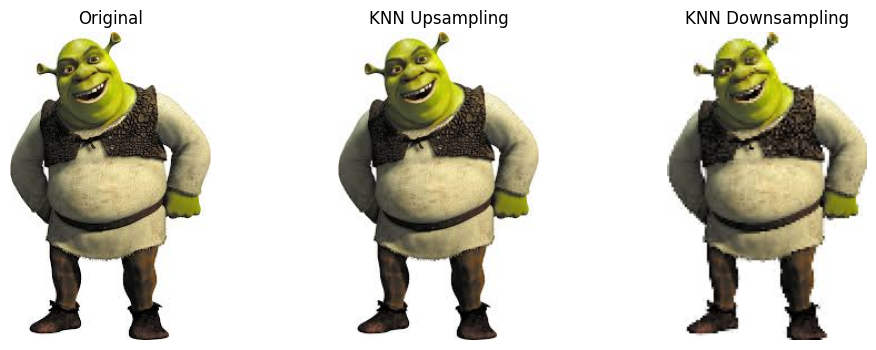

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/content/shrek.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Upsampling using Nearest Neighbor (KNN interpolation)
knn_up = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)

# Downsampling example
knn_down = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)

# Display
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title('Original'); plt.imshow(img); plt.axis('off')
plt.subplot(1,3,2); plt.title('KNN Upsampling'); plt.imshow(knn_up); plt.axis('off')
plt.subplot(1,3,3); plt.title('KNN Downsampling'); plt.imshow(knn_down); plt.axis('off')
plt.show()
